# VaLPAS Framework Overview

### Introduction to VaLPAS
VaLPAS is a framework to establish and investigate functional relations between proteins and other "omics" data. This notebook provides an overview of VaLPAS functionality and demonstrates how to leverage its core capabilities.


In [29]:
# iPython magic to autoreload modules everytime code is executed to propagate changes to the code
%load_ext autoreload
%autoreload 2

# loading '/src' into sys path
import os
import sys
import valpas
from pathlib import Path

# don't show warnings
import warnings
warnings.filterwarnings('ignore')
    
# Import necessary modules
from valpas.valpas_core import associate, prepare, visualize


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set up path names for example data

In [20]:
# path to the csv containing the proteome data
fpath_prot_csv = Path(os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "in_test_data",
    "rhodo_test_data__proteomics.csv"
    ))

# path to the csv containing the metabolomics data
fpath_metabol_csv = Path(os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "in_test_data",
    "rhodo_test_data__metabolomics.csv"
    ))

# path to the excel file containing both the proteomics and metabolomics data
fpath_input_xlsx = Path(os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "in_test_data",
    "rhodo_test_data.xlsx"
))

# path to the folder that contains all test input files
path_infiles_folder = Path(os.path.join(
    os.getcwd(),
    '..',
    'sample_data',
    'in_test_data'
))

# path to the csv and excel outfiles
fpath_output_assoc_list_csv = Path(os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_metabol-metabol_assoc_list.csv"
))
fpath_output_assoc_mat_csv = Path(os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_prot-metabol_assoc_mat.csv"
))
fpath_output_xlsx = Path(os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_out.xlsx"
))

## 1. Input Preparation
The prepare function is responsible for validating and preparing datasets within VaLPAS. It ensures that input files are correctly loaded and meet the preprocessing requirements.

Usage of prepare Function:

In [21]:
# Example of preparing metabolomics data
experiments = prepare(
    infile=fpath_metabol_csv,
    file_type="csv"
)

# Display the prepared experiments (optional)
print("Prepared Experiments:", experiments)


Prepared Experiments: [<valpas._core.classes.experiments.SingleExperiment object at 0x12215a270>]


## 2. Generating Associations
The associate function enables the generation of association scores between data points based on various metrics (e.g., Pearson correlation, Spearman, Jaccard similarity).

Usage of associate Function:

In [25]:
sheet = "Metabolomics"
sheet2 = "Proteomics"
sheet_names = [sheet]
sheet_names = sheet_names + [sheet2]
sheet_names

['Metabolomics', 'Proteomics']

In [22]:
# Example: Generating associations between metabolomics data points
association_result = associate(
    association_type="spearman",          # Type of association metric
    infile=fpath_metabol_csv,            # Input file
    filter_cutoff=0.5,                   # Filter cutoff for missing values
    output_type="sorted_list",           # Output format
    outfile=fpath_output_assoc_list_csv  # Path for saving the result
)

# Display the association result
print("Association Result:", association_result)

Association Result: <valpas._core.classes.results.AssociationResult object at 0x12215a3c0>


In [35]:
# Example: Generating mutual information associations between Proteomics and Metabolomics
association_matrix_result = associate(
    association_type="mutual_information",  # Association metric
    infile=fpath_input_xlsx,                # Input Excel file
    file_type='xlsx',
    sheet="Metabolomics",                   # Excel sheet name 1
    sheet2="Proteomics",                    # Excel sheet name 2
    output_type="correlation_matrix",       # Output format
    filter_cutoff=0.5,                      # Filter cutoff
    outfile=fpath_output_assoc_mat_csv      # Path for saving the association matrix
)

print("Association Matrix File Saved:", fpath_output_assoc_mat_csv)


Association Matrix File Saved: /Users/d3p620/lib/valpas-prototype/notebooks/../sample_data/out/rhodo_test_prot-metabol_assoc_mat.csv


In [42]:
association_matrix_result.values

Proteomics,"1,3-dihydroxyacetone",2-furoic acid,2-hydroxyglutaric acid
Metabolomics,,,
8372,0.970951,1.5,1.521928
8373,1.500000,1.5,2.000000


## 3. Data Visualization
The visualize function provides tools to visualize the results from association analysis. The current implementation supports heatmap generation and other visualizations.

Usage of visualize Function:

AttributeError: 'NoneType' object has no attribute 'show'

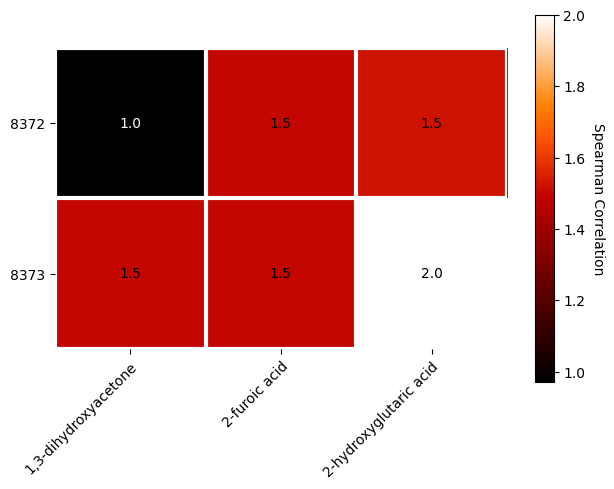

In [37]:
# Example: Visualize the association matrix as a heatmap
fpath_fig = os.path.join(
    os.getcwd(),
    "..",
    "sample_data",
    "out",
    "rhodo_test_prot_corr_mat.png"
    )

heatmap_fig = visualize(
    infile=fpath_output_assoc_mat_csv,  # Path to input datafile (association matrix)
    visualization_type="heatmap",      # Visualization type (heatmap)
    label="Spearman Correlation",      # Color bar label
    outfile=fpath_fig                  # Path to save the generated heatmap
)
